In [1]:
import torch
from torch import nn
from torch.nn import functional as F

import matplotlib.pyplot as plt
import numpy as np

In [77]:
class MNISTMLP(nn.Module):
    
    def __init__(self, d):
        super().__init__()
        self.fc1 = nn.Linear(28*28, d)
        self.fc2 = nn.Linear(d, 10)
        
        self.z1 = torch.tensor(0)
        self.z2 = torch.tensor(0)
        
    def forward(self, x):
        # input x must have shape: (batch_size, 28*28)

        self.z1 = F.relu(self.fc1(x))
        self.z2 = self.fc2(self.z1)
        
        return F.softmax(self.z2, dim=1)
    
x = torch.randn(32, 28*28)
mnist_mlp = MNISTMLP(d=20)
mnist_mlp(x).shape

torch.Size([32, 10])

In [78]:
import torchvision
import torchvision.transforms as transforms

DOWNLOAD_PATH = '../datasets'

# normalize so that the mean of the data is zero and the variance is one
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

train_val = torchvision.datasets.MNIST(root=DOWNLOAD_PATH, train=True, download=True, transform=transform)
test = torchvision.datasets.MNIST(root=DOWNLOAD_PATH, train=False, download=True, transform=transform)
train, val = torch.utils.data.random_split(train_val, [55000, 5000])

len(train), len(val), len(test)

(55000, 5000, 10000)

In [79]:
from torch.utils.data import DataLoader

batch_size = 64
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test, batch_size=len(test), shuffle=True)
val_loader = DataLoader(val, batch_size=len(val), shuffle=True)

In [80]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [81]:
def train_MNIST(model, lr, epochs, verbose=False):
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    train_history = []
    val_history = []

    for e in range(epochs):
        batch_history = []
        # TRAIN STEP
        for images, labels in train_loader:
            # convert images to the correct device (GPU or CPU)
            images, labels = images.flatten(start_dim=1).to(device), labels.to(device)
            # predict and compute loss
            preds = model(images)
            loss = F.nll_loss(torch.log(preds), labels)
            batch_history.append(loss.item())
            # optimization step
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_history.append(np.mean(batch_history))

        batch_history = []
        # VALIDATION STEP
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.flatten(start_dim=1).to(device), labels.to(device)
                preds = model(images)
                loss = F.nll_loss(torch.log(preds), labels)
                batch_history.append(loss.item())
            val_history.append(np.mean(batch_history))
        
        if verbose: print(f"epoch: {e}\ttrain loss: {train_history[-1]:.4f}\tval loss: {val_history[-1]:.4f}")
    
    return train_history, val_history

In [83]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 10
learning_rate = 0.001
d = 128

model = MNISTMLP(d=d).to(device)

In [84]:
train_histories, val_histories = [], []

train_history, val_history = train_MNIST(model, learning_rate, EPOCHS, verbose=True)

train_histories.append(train_history)
val_histories.append(val_history)

epoch: 0	train loss: 0.3859	val loss: 0.2439
epoch: 1	train loss: 0.2011	val loss: 0.1692
epoch: 2	train loss: 0.1457	val loss: 0.1483
epoch: 3	train loss: 0.1139	val loss: 0.1170
epoch: 4	train loss: 0.0973	val loss: 0.1141
epoch: 5	train loss: 0.0859	val loss: 0.1157
epoch: 6	train loss: 0.0768	val loss: 0.1228
epoch: 7	train loss: 0.0683	val loss: 0.0993
epoch: 8	train loss: 0.0612	val loss: 0.0916
epoch: 9	train loss: 0.0559	val loss: 0.0982


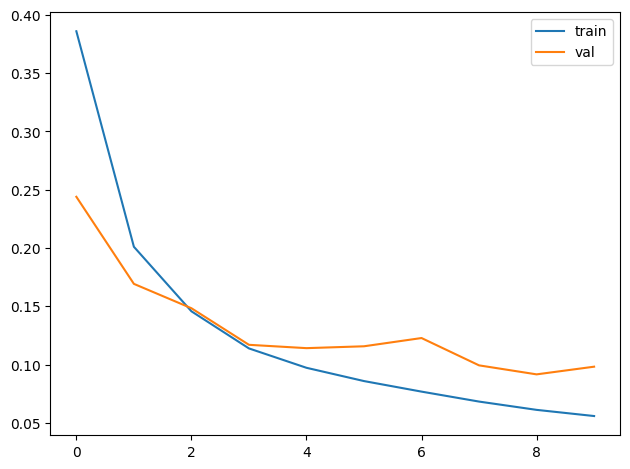

In [85]:
plt.plot(train_histories[0], label='train')
plt.plot(val_histories[0], label='val')
plt.legend()

plt.tight_layout()

In [86]:


test_acc, test_loss = 0, 0
# VALIDATION STEP
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.flatten(start_dim=1).to(device), labels.to(device)
        preds = model(images)
        loss = F.nll_loss(torch.log(preds), labels)
        test_loss += loss.item()
        test_acc += sum(preds.argmax(dim=-1) == labels).item()

test_loss, test_acc / len(test)

(0.09281281381845474, 0.9723)

In [87]:
z1 = model.z1.detach().cpu().numpy()
z2 = model.z2.detach().cpu().numpy()

z1.shape, z2.shape

((10000, 128), (10000, 10))

In [91]:
def SRM(thetas, DL, eps, bi, bj):

    m = DL.shape[1]

    # bi = np.zeros((m,))
    # bi[alpha] = 1
    # bj = np.zeros((m,))
    # bj[beta] = 1

    bivector = 0.5 * (np.outer(bi, bj) - np.outer(bj, bi))
    eigvals, eigvecs = np.linalg.eig(bivector)

    di = np.diag_indices(m)
    Lambda = np.zeros((m, m), dtype=np.complex64)
    Lambda[di] = eigvals

    R_ij = eigvecs @ np.exp(thetas[..., None, None] * Lambda) @ np.conj(eigvecs.T)

    freqs = np.sum((DL @ R_ij @ bi) >= eps, axis=1) / DL.shape[0]
    return freqs

In [102]:
from sklearn.decomposition import PCA

m = 10 #z1.shape[1]

pca = PCA(n_components=m)
pca.fit(z1)

pca.components_.shape

(10, 128)

In [103]:
from tqdm import tqdm

thetas = np.linspace(0.1, 2*np.pi, 200)
eps = 0.001

freqs = []

for alpha in tqdm(range(m)):
    
    per_logit = []

    for beta in tqdm(range(m)):
        
        if alpha == beta: continue

        per_logit.append(SRM(thetas, z1, eps, pca.components_[alpha], pca.components_[beta]))
    
    freqs.append(per_logit)

100%|██████████| 10/10 [04:49<00:00, 28.92s/it]


In [104]:
per_logit_freqs = np.stack(freqs)

per_logit_freqs.shape

(10, 9, 200)

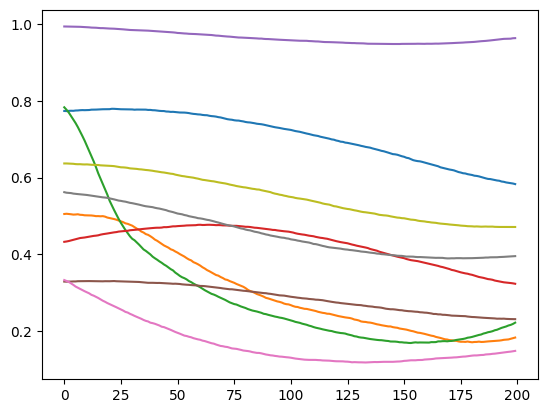

In [129]:
plt.plot(per_logit_freqs[4].T)
plt.show()

In [130]:
from sklearn.decomposition import PCA

m = 10 #z1.shape[1]

pca = PCA(n_components=m)
pca.fit(z2)

pca.components_.shape

(10, 10)

In [131]:
from tqdm import tqdm

thetas = np.linspace(0.1, 2*np.pi, 200)
eps = 0.001

freqs = []

for alpha in tqdm(range(m)):
    
    per_logit = []

    for beta in tqdm(range(m)):
        
        if alpha == beta: continue

        per_logit.append(SRM(thetas, z2, eps, pca.components_[alpha], pca.components_[beta]))
    
    freqs.append(per_logit)

100%|██████████| 10/10 [00:13<00:00,  1.32s/it]


In [132]:
per_logit_freqs = np.stack(freqs)

per_logit_freqs.shape

(10, 9, 200)

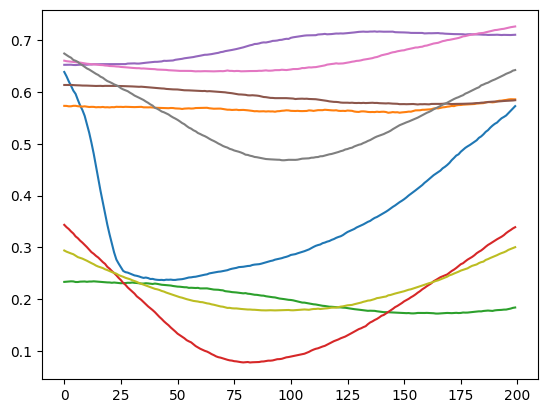

In [136]:
plt.plot(per_logit_freqs[3].T)
plt.show()